In [1]:
#5問目
import re
prog = re.compile(r'py?(th|ers)oni?(a[lmn]|c)?', re.IGNORECASE)
words = ['Python', 'personal', 'pythomian', 'PYTHONIC', 'The Zen of Python']

for word in words:
    ret = prog.search(word)
    if ret is None:
        print('error')
    else:
        print(ret[0])

Python
personal
error
PYTHONIC
Python


正規表現
a?で a はあってもなくても
(a|b) aか b か　どっちか
[abc] aかbかcか
re.IGNORECASE　で大文字、小文字の分別無し

In [2]:
#pickleの復習
import pickle
from datetime import datetime, date
d = {'today': date.today(),
     'delta': date(2025, 3, 1) - date.today()}

d

{'today': datetime.date(2026, 6, 7), 'delta': datetime.timedelta(days=-463)}

In [ ]:
pickle.dumps(d) #データの直列化

b'\x80\x04\x95Q\x00\x00\x00\x00\x00\x00\x00}\x94(\x8c\x05today\x94\x8c\x08datetime\x94\x8c\x04date\x94\x93\x94C\x04\x07\xea\x06\x07\x94\x85\x94R\x94\x8c\x05delta\x94h\x02\x8c\ttimedelta\x94\x93\x94J1\xfe\xff\xffK\x00K\x00\x87\x94R\x94u.'

In [4]:
with open('date.pkl', 'wb') as f: #ファイルをバイト書き込みモードで開く
    pickle.dump(d, f)  #pickle形式で保存
    
with open('date.pkl', 'rb') as f: #ファイルを読み込みモードで開く
    new_d = pickle.load(f)  #pickle形式のデータを読み込む
    
new_d

{'today': datetime.date(2026, 6, 7), 'delta': datetime.timedelta(days=-463)}

In [5]:
#pathlibモジュール
from pathlib import Path
p = Path() #Pathオブジェクトを現在のディレクトリで作成
p

WindowsPath('.')

In [9]:
p = Path('date.pkl')
p.exists()

True

In [10]:
p.is_dir()

False

In [1]:
#ジェネレーター式を作成
g = (x*x for x in range(1000))
g

<generator object <genexpr> at 0x000001D34B4C2F60>

In [2]:
print(type(g))
next(g), next(g), next(g)

<class 'generator'>


(0, 1, 4)

In [3]:
with open('sample.text', 'w', encoding='utf-8') as f:
    f.write('こんにちは\n')
    f.write('Python\n')

In [5]:
f.closed

True

In [6]:
with open('sample.text', encoding='utf-8') as f:
    data = f.read()
data

'こんにちは\nPython\n'

In [7]:
from datetime import datetime, date
datetime.now()

datetime.datetime(2026, 6, 9, 14, 17, 12, 329388)

In [8]:
date.today()

datetime.date(2026, 6, 9)

In [9]:
date.today() - date(2008, 2, 6)

datetime.timedelta(days=6698)

In [10]:
f'{date.today().strftime('%Y年%m月%d日')}'

'2026年06月09日'

In [11]:
import numpy as np
a = np.array([1, 2, 4])
type(a)

numpy.ndarray

In [12]:
a.dtype

dtype('int64')

In [13]:
a.shape

(3,)

In [16]:
a = np.arange(1, 10, 3)
a

array([1, 4, 7])

In [18]:
b = np.eye(5)
b

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

In [19]:
a = np.array([1, 2, 3])
a1 = np.array([4, 5, 6])
np.concatenate([a, a1])

array([1, 2, 3, 4, 5, 6])

In [24]:
b = np.array([[1, 2, 6],
              [4, 5, 7]])
b1=np.array([[10],
            [20]])
np.concatenate([b, b1], axis=1)

array([[ 1,  2,  6, 10],
       [ 4,  5,  7, 20]])

In [25]:
np.hstack([b, b1])

array([[ 1,  2,  6, 10],
       [ 4,  5,  7, 20]])

In [26]:
np.vstack([a, a1])

array([[1, 2, 3],
       [4, 5, 6]])

In [27]:
np.hstack([a, a1])

array([1, 2, 3, 4, 5, 6])

In [28]:
b2 = np.array([30, 45, 60])
b3 = np.vstack([b, b2])
b3

array([[ 1,  2,  6],
       [ 4,  5,  7],
       [30, 45, 60]])

In [29]:
first, second = np.hsplit(b3, [2])
first

array([[ 1,  2],
       [ 4,  5],
       [30, 45]])

In [30]:
first, second = np.vsplit(b3, [2])
first

array([[1, 2, 6],
       [4, 5, 7]])

In [31]:
a

array([1, 2, 3])

In [32]:
a[np.newaxis, :]

array([[1, 2, 3]])

In [33]:
a[:, np.newaxis]

array([[1],
       [2],
       [3]])

In [35]:
import pandas as pd
df = pd.DataFrame([[40, 'a', True],
                   [20, 'b', False],
                   [30, 'c', False]])
df.index = ['01', '02', '03”']
df.columns = ['A', 'B', 'C']
df

,A,B,C
01,40,a,True
02,20,b,False
03”,30,c,False


In [ ]:
def judge(arg):
    if arg <50:
        return 'low'
    elif arg < 70:
        return 'middle'
    else:
        return 'high'

df.loc[:, 'C'] = df.iloc[:, 0]*2
df.loc[:, 'B'] = df.iloc[:, 2].apply(judge)
_ = df['C'] > 50  #条件による抽出　Seriesで返す
_

01      True
02     False
03”     True
Name: C, dtype: bool

In [38]:
df = df[_]
df

,A,B,C
01,40,high,80
03”,30,middle,60


In [39]:
df_selected = df.loc[df['C']>50]
df_selected

,A,B,C
01,40,high,80
03”,30,middle,60


In [45]:
import numpy as np
np.random.seed(123)
dates = pd.date_range(start='2017-04-01', periods=365)
df = pd.DataFrame(np.random.randint(1, 31, 365), index=dates, columns=['rand'])

dates

DatetimeIndex(['2017-04-01', '2017-04-02', '2017-04-03', '2017-04-04',
               '2017-04-05', '2017-04-06', '2017-04-07', '2017-04-08',
               '2017-04-09', '2017-04-10',
               ...
               '2018-03-22', '2018-03-23', '2018-03-24', '2018-03-25',
               '2018-03-26', '2018-03-27', '2018-03-28', '2018-03-29',
               '2018-03-30', '2018-03-31'],
              dtype='datetime64[ns]', length=365, freq='D')

In [46]:
df.head(9)

,rand
2017-04-01,14
2017-04-02,3
2017-04-03,29
2017-04-04,3
2017-04-05,7
2017-04-06,18
2017-04-07,20
2017-04-08,11
2017-04-09,28


In [48]:
df_year = pd.DataFrame(df.groupby(pd.Grouper(freq='W-SAT')).sum(), columns=['rand'])
df_year.head()  #一週間の合計　土曜日で表示

,rand
2017-04-01,14
2017-04-08,91
2017-04-15,114
2017-04-22,89
2017-04-29,91


In [50]:
df_month = pd.DataFrame(df.groupby(pd.Grouper(freq='M')).sum(), columns=['rand'])
df_month

C:\Users\shige\AppData\Local\Temp\ipykernel_32024\3367942069.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_month = pd.DataFrame(df.groupby(pd.Grouper(freq='M')).sum(), columns=['rand'])


,rand
2017-04-30,423
2017-05-31,395
2017-06-30,495
2017-07-31,472
2017-08-31,478
2017-09-30,412
2017-10-31,495
2017-11-30,472
2017-12-31,550
2018-01-31,470


In [51]:
df.groupby(pd.Grouper(freq='ME')).mean()#月平均

,rand
2017-04-30,14.100000
2017-05-31,12.741935
2017-06-30,16.500000
2017-07-31,15.225806
2017-08-31,15.419355
2017-09-30,13.733333
2017-10-31,15.967742
2017-11-30,15.733333
2017-12-31,17.741935
2018-01-31,15.161290


In [ ]:
df.groupby(pd.Grouper(freq='ME')).mean().values #.valuesでnumpy配列に変換　インデックス、カラム名は保存できない　

array([[14.1       ],
       [12.74193548],
       [16.5       ],
       [15.22580645],
       [15.41935484],
       [13.73333333],
       [15.96774194],
       [15.73333333],
       [17.74193548],
       [15.16129032],
       [12.57142857],
       [17.48387097]])

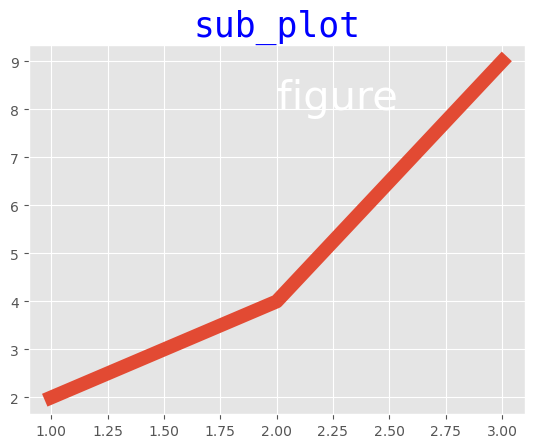

In [58]:
import matplotlib.pyplot as plt
import matplotlib.style

matplotlib.style.use('ggplot')

x = [1, 2, 3]
y = [2, 4, 9]

fig, ax = plt.subplots()
ax.plot(x, y, linewidth=10)
ax.set_title('sub_plot', size=25, color='blue', family='monospace')
ax.text(2.00, 8.00, 'figure', size='30', color='white')
plt.show()

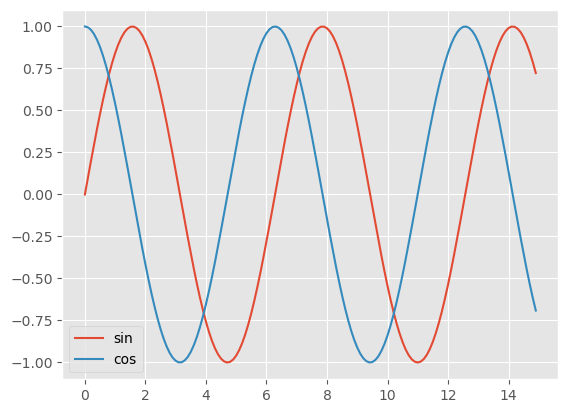

In [59]:
import numpy as np
x = np.arange(0.0, 15.0, 0.1)
y1 = np.sin(x)
y2 = np.cos(x)
fig, ax = plt.subplots()
ax.plot(x, y1, label='sin')
ax.plot(x, y2, label='cos')
ax.legend()
plt.show()

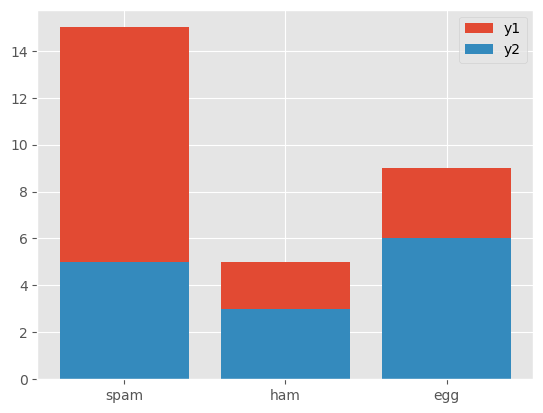

In [60]:
fig, ax = plt.subplots()
x = [1, 2, 3]
y1 = [10, 2, 3]
y2 = [5, 3, 6]
labels = ['spam', 'ham', 'egg']
y_total = [num1 + num2 for num1, num2, in zip(y1, y2)]
ax.bar(x, y_total, tick_label=labels, label='y1')
ax.bar(x, y2, label='y2')
ax.legend()
plt.show()

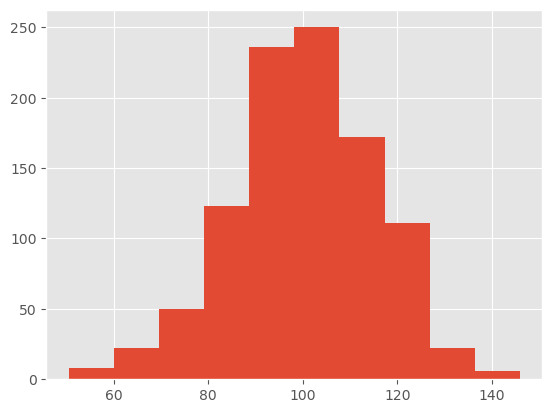

In [61]:
rng = np.random.default_rng(123)
mu = 100
sigma = 15
x = rng.normal(mu, sigma, 1000)
fig, ax = plt.subplots()
n, bins, patches = ax.hist(x)
plt.show()

In [ ]:
n #度数　各瓶の要素数

array([  8.,  22.,  50., 123., 236., 250., 172., 111.,  22.,   6.])

In [ ]:
bins  #各瓶の境界の値

array([ 50.52577952,  60.06056773,  69.59535594,  79.13014416,
        88.66493237,  98.19972059, 107.7345088 , 117.26929701,
       126.80408523, 136.33887344, 145.87366165])

In [64]:
for i, num in enumerate(n):
    print(f'{bins[i]:.2f} - {bins[i+1]:.2f}: {num}')

50.53 - 60.06: 8.0
60.06 - 69.60: 22.0
69.60 - 79.13: 50.0
79.13 - 88.66: 123.0
88.66 - 98.20: 236.0
98.20 - 107.73: 250.0
107.73 - 117.27: 172.0
117.27 - 126.80: 111.0
126.80 - 136.34: 22.0
136.34 - 145.87: 6.0


51.53 - 55.62 : 2.0
55.62 - 59.70 : 3.0
59.70 - 63.78 : 6.0
63.78 - 67.86 : 7.0
67.86 - 71.94 : 16.0
71.94 - 76.02 : 29.0
76.02 - 80.11 : 37.0
80.11 - 84.19 : 65.0
84.19 - 88.27 : 57.0
88.27 - 92.35 : 90.0
92.35 - 96.43 : 105.0
96.43 - 100.51 : 115.0
100.51 - 104.59 : 116.0
104.59 - 108.68 : 78.0
108.68 - 112.76 : 74.0
112.76 - 116.84 : 77.0
116.84 - 120.92 : 42.0
120.92 - 125.00 : 41.0
125.00 - 129.08 : 21.0
129.08 - 133.17 : 10.0
133.17 - 137.25 : 4.0
137.25 - 141.33 : 2.0
141.33 - 145.41 : 2.0
145.41 - 149.49 : 0.0
149.49 - 153.57 : 1.0


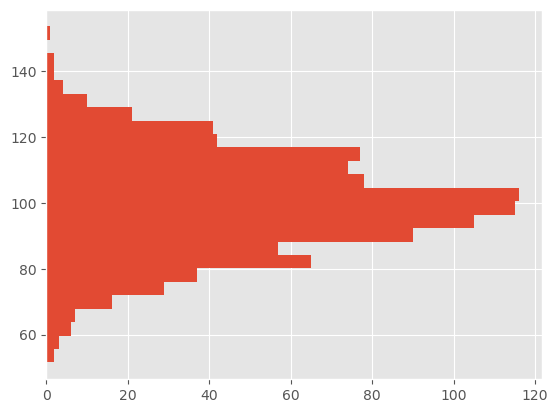

In [67]:
np.random.seed(123)
mu = 100
sigma = 15
x = np.random.normal(mu, sigma, 1000)
fig, ax = plt.subplots()
n, bins, patches = ax.hist(x, bins=25, orientation='horizontal')
for i, num in enumerate(n):
    print('{:.2f} - {:.2f} : {}'.format(bins[i], bins[i+1], num))
plt.show()

In [68]:
for patch in patches:
    print(patch)

Rectangle(xy=(0, 51.5342), width=2, height=4.08158, angle=0)
Rectangle(xy=(0, 55.6158), width=3, height=4.08158, angle=0)
Rectangle(xy=(0, 59.6973), width=6, height=4.08158, angle=0)
Rectangle(xy=(0, 63.7789), width=7, height=4.08158, angle=0)
Rectangle(xy=(0, 67.8605), width=16, height=4.08158, angle=0)
Rectangle(xy=(0, 71.9421), width=29, height=4.08158, angle=0)
Rectangle(xy=(0, 76.0237), width=37, height=4.08158, angle=0)
Rectangle(xy=(0, 80.1052), width=65, height=4.08158, angle=0)
Rectangle(xy=(0, 84.1868), width=57, height=4.08158, angle=0)
Rectangle(xy=(0, 88.2684), width=90, height=4.08158, angle=0)
Rectangle(xy=(0, 92.35), width=105, height=4.08158, angle=0)
Rectangle(xy=(0, 96.4316), width=115, height=4.08158, angle=0)
Rectangle(xy=(0, 100.513), width=116, height=4.08158, angle=0)
Rectangle(xy=(0, 104.595), width=78, height=4.08158, angle=0)
Rectangle(xy=(0, 108.676), width=74, height=4.08158, angle=0)
Rectangle(xy=(0, 112.758), width=77, height=4.08158, angle=0)
Rectangle(x

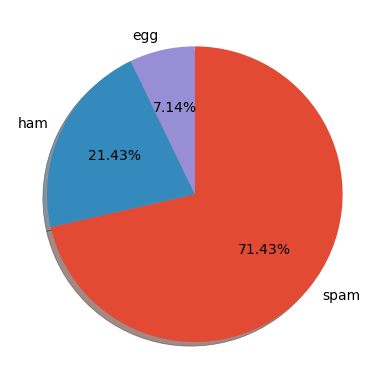

In [72]:
labels = ['spam', 'ham', 'egg']
x = [10, 3, 1]
fig, ax = plt.subplots()
ax.pie(x, labels=labels, startangle=90, counterclock=False, 
       shadow=True, autopct='%1.2f%%')
plt.show()

In [ ]:
#機械学習の前処理  カテゴリ変数のエンコーディング
import pandas as pd
df = pd.DataFrame({'blood type':['A', 'B', 'AB', 'O', 'A', 'O']})
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() #インスタンスの生成
le.fit_transform(df['blood type'])

array([0, 2, 1, 3, 0, 3])

In [78]:
#One-hotエンコーディング
df = pd.DataFrame({'blood type':['A', 'B', 'AB', 'O', 'A', 'O']})
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
enc.fit_transform(df['blood type'])

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.